In [ ]:
import os  # Importa o módulo para interagir com o sistema operacional (definir variáveis de ambiente)
import re  # Importa o módulo de Expressões Regulares para limpeza e manipulação de textos
import pandas as pd  # Importa o Pandas para ler, estruturar e manipular os dados em tabelas (DataFrames)
import seaborn as sns # Importa o seaborn (biblioteca resposnavel por desenhar os graficos bonitos) para geração de gráficos (como o mapa de calor)
import matplotlib.pyplot as plt # Importa o Pyplot do Matplotlib para controle de layouts, títulos e exibição de gráficos na tela
from sklearn.metrics import confusion_matrix # Importa a função matemática específica para calcular e gerar a Matriz de confusão
from sklearn.model_selection import train_test_split  # Importa a função para dividir os dados em treino e teste
from sklearn.feature_extraction.text import TfidfVectorizer  # Importa o transformador de texto em números matemáticos
from sklearn.linear_model import LogisticRegression  # Importa o algoritmo que calcula o "peso" emocional das palavras
from sklearn.pipeline import Pipeline  # Importa o Pipeline para encadear as etapas de preparação e classificação
from sklearn.metrics import accuracy_score, classification_report  # Importa as ferramentas para calcular a porcentagem de acertos da IA e outras métricas de classificação

# Minhas credenciais do Kaggle
# Define a chave secreta de autenticação para conseguir acessar a API do Kaggle
os.environ["KAGGLE_API_TOKEN"] = "KGAT_281fabb8ee79ca3f964e63aa066405a2"

# Baixa o dataset de 1.6M de comentários em inglês
# Baixa o arquivo compactado contendo a base de dados Sentiment140 do Kaggle
!kaggle datasets download -d kazanova/sentiment140

# Extrai o arquivo zip de forma silenciosa salvando os dados na pasta /content
!unzip -q sentiment140.zip -d /content/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
100% 80.9M/80.9M [00:01<00:00, 83.7MB/s]



In [ ]:
print("Carregando 1.6 milhões de tweets...")

# 1. Definimos os nomes das colunas manualmente porque o arquivo original vem sem cabeçalho
# Cria uma lista com os nomes textuais das 6 colunas do arquivo do Sentiment140
nomes_colunas = ['target', 'id', 'date', 'flag', 'user', 'text']

# Carrega o CSV definindo o caminho do arquivo, a codificação de caracteres correta e os nomes das colunas criadas acima
# ISO é o padrão de 2009 para ler os arquivos
df = pd.read_csv('/content/sentiment140/training.1600000.processed.noemoticon.csv',encoding='ISO-8859-1',names=nomes_colunas)

# 2. No Sentiment140, 4 significa Positivo. Mudamos para 1 para a IA entender melhor.
# Localiza onde está o número 4 na coluna de respostas e substitui pelo número 1
df['target'] = df['target'].replace(4, 1)

# 3. Criamos a nova função de limpeza adaptada para o Inglês
# Define a função responsável por remover sujeiras específicas do texto em inglês
def limpar_texto_en(texto):
    texto = re.sub(r"http\S+", "", texto)  # Remove links (Localiza links de internet e os apaga)
    texto = re.sub(r"@\S+", "", texto)   # Remove menções (@user) (Localiza usuários e os apaga)
    texto = texto.lower()                 # Letras minúsculas (Padroniza todo o texto em minúsculo)
    # Remove manualmente variações de carinhas/emojis baseados em texto que restaram no arquivo ⬇
    texto = texto.replace(":)", "").replace(":(", "").replace(":D", "").replace(":-", "").replace(":-(", "")
    return texto                          # Devolve o texto em inglês limpo

print("Limpando os textos em inglês...")

# Aplica a função de limpeza linha por linha na coluna 'text' e salva o resultado na nova coluna 'texto_limpo'
df['texto_limpo'] = df['text'].apply(limpar_texto_en)

# 4. Mantém no DataFrame apenas as colunas necessárias para o treino da IA (o sentimento (negativo ou positivo) e o texto)
df = df[['target', 'texto_limpo']]

# Reparte os dados: 80% vai para o treino da IA e 20% fica guardado em segredo para teste de acurácia
X_train, X_test, y_train, y_test = train_test_split(
    df['texto_limpo'],  # Passa a coluna contendo as frases em inglês limpas (X)
    df['target'],       # Passa a coluna contendo as respostas numéricas 0 e 1 (y)
    test_size=0.2,      # Define que a proporção do teste será de 20% do total
    random_state=42     # Fixa uma semente aleatória para garantir que o sorteio seja sempre igual
)

print("Dados prontos e divididos!")

Carregando 1.6 milhões de tweets...
Limpando os textos em inglês...
Dados prontos e divididos!


In [ ]:
print("\n==========================================================================")
print("Visualização das colunas do dataset que serão utilizadas:")
display(df.head()) # Exibe as 5 primeiras linhas da tabela para verificar visualmente o resultado da limpeza dos textos

print("\n==========================================================================")
print("Visualização da quantidade e o tipo de dados disponíveis nas duas colunas:")
print(" ")
display(df.info()) # Mostra o resumo técnico da tabela: a quantidade total de linhas, o nome das colunas e os tipos de dados


Visualização das colunas do dataset que serão utilizadas:


,target,texto_limpo
0,0,"- awww, that's a bummer. you shoulda got da..."
1,0,is upset that he can't update his facebook by ...
2,0,i dived many times for the ball. managed to s...
3,0,my whole body feels itchy and like its on fire
4,0,"no, it's not behaving at all. i'm mad. why am..."



Visualização da quantidade e o tipo de dados disponíveis nas duas colunas:
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 2 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   target       1600000 non-null  int64 
 1   texto_limpo  1600000 non-null  object
dtypes: int64(1), object(1)
memory usage: 24.4+ MB


None

In [ ]:
print("Configurando a IA...")

# Encadeia o fluxo da IA: primeiro transforma o texto limpo em número(tfidf) e depois envia os dados para o classificador matemático(clf)
modelo_ia_en = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 3),      # Analisa palavras soltas, duplas e trios em inglês
        max_features=100000,     # Limita o dicionário em 100 mil termos para o Colab não estourar a memória RAM
        sublinear_tf=True        # Suaviza palavras que se repetem muito no mesmo comentário (ajusta a contagem matematicamente)
    )),
    ('clf', LogisticRegression(
        C=5.0,                   # Ajuste matemático para dar mais precisão (força o modelo a ajustar melhor os pesos)
        max_iter=1000,           # Dá tempo suficiente (iterações) para a matemática do algoritmo convergir e achar a resposta
        n_jobs=-1                # Faz o Colab usar toda a velocidade do processador (usa todos os núcleos em paralelo para ir rápido)
    ))
])

print("Treinando modelo com mais de 1 milhão de frases... (Vai demorar entre 2 a 4 minutos)")

# Inicia o treinamento real fazendo a IA calcular os pesos das palavras do texto associadas aos alvos (0 ou 1)
modelo_ia_en.fit(X_train, y_train)

print("Treinamento concluído com sucesso!")


Configurando a IA...
Treinando modelo com mais de 1 milhão de frases... (Vai demorar entre 2 a 4 minutos)
Treinamento concluído com sucesso!


In [ ]:
# Salva o modelo treinado em disco
import pickle

with open("modelo_sentimentos.pkl", "wb") as f:
    pickle.dump(modelo_ia_en, f)

print("Modelo salvo como modelo_sentimentos.pkl")
print("Baixe este arquivo pelo painel lateral do Colab (ícone de pasta).")

In [ ]:
print("Calculando os acertos nos dados de teste da IA...")

# Faz a inteligência artificial prever as respostas de todas as frases guardadas para o teste (20%)
previsoes = modelo_ia_en.predict(X_test)

# Compara as previsões feitas com os gabaritos reais (y_test) e calcula o percentual geral de acertos
acuracia = accuracy_score(y_test, previsoes)

# Exibe na tela a eficácia final do modelo multiplicando por 100 para mostrar em formato de porcentagem
print(f"\nPorcentagem de acerto final da IA: {acuracia * 100:.2f}%")

# Gera um relatório completo das métricas de classificação, incluindo Precision, Recall e F1-Score
# para as classes 0 (Negativo) e 1 (Positivo).
# 'target_names' ajuda a identificar qual métrica pertence a qual classe.
# A coluna 'support' contém a quantidade de comentarios utilizados para treinar (20% de 1,6 milhão = 320 mil).
relatorio_classificacao = classification_report(y_test, previsoes, target_names=['Negativo', 'Positivo'])
print("\nRelatório de Classificação Detalhado:\n")
print(relatorio_classificacao)

Calculando os acertos nos dados de teste da IA...

Porcentagem de acerto final da IA: 82.00%

Relatório de Classificação Detalhado:

              precision    recall  f1-score   support

    Negativo       0.83      0.81      0.82    159494
    Positivo       0.81      0.83      0.82    160506

    accuracy                           0.82    320000
   macro avg       0.82      0.82      0.82    320000
weighted avg       0.82      0.82      0.82    320000



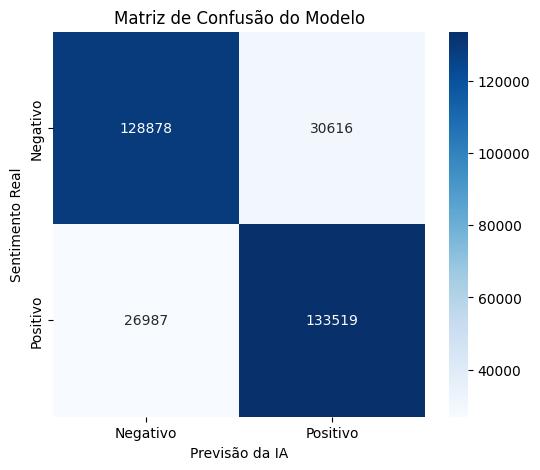

In [ ]:
# Calcula os erros e acertos  cruzando os dados reais (y_test) com as previsões da IA
cm = confusion_matrix(y_test, previsoes)

# Define a largura e a altura da janela onde o gráfico será desenhado (em polegadas)⬇
plt.figure(figsize=(6, 5))
# Cria o mapa de calor azul(heatmap), inserindo a matriz e configurando os rótulos dos eixos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'], # Altera as legendas dos eixos x (horizontal) que era pra ser 0 e 1 e vira negativo e positivo
            yticklabels=['Negativo', 'Positivo']) # Altera as legendas dos eixos y (vertical) que era pra ser 0 e 1 e vira negativo e positivo

# Define o texto que aparece na parte de baixo do gráfico (eixo X)
plt.xlabel('Previsão da IA')

# Define o texto que aparece na lateral esquerda do gráfico (eixo Y)
plt.ylabel('Sentimento Real')

# Adiciona o título principal na parte superior do gráfico
plt.title('Matriz de Confusão do Modelo')

# Finaliza e renderiza o gráfico desenhado na tela
plt.show()

In [ ]:
print("\n=======================================================")
print(" Classificador de Sentimentos de Tweets em Inglês")
print("=======================================================")
print(" Digite uma frase para classificar o sentimento.")
print(" Digite 'sair' (ou 'exit') para encerrar o programa.")
print("=======================================================")

# Loop contínuo para permitir múltiplas classificações até o usuário decidir sair
while True:
    print("\n-------------------------------------------------------")
    frase = input(" Digite seu comentário (para encerrar: sair/exit): ")

    # Verifica se o usuário deseja sair do programa
    if frase.lower() == 'sair' or frase.lower() == 'exit':
        break

    # Usa o pipeline diretamente para prever o sentimento da frase digitada
    # O pipeline (modelo_ia_en) já inclui a vetorização (TF-IDF) e o modelo de classificação (Regressão Logística).
    # Passamos a frase em uma lista(frase), pois o método predict espera uma entrada iterável, isto é, uma frase inteira, e não caracteres separados.
    resultado = modelo_ia_en.predict([frase])

    # Traduz o resultado numérico (0 ou 1) para um texto descritivo (Negativo ou Positivo)
    # O modelo retorna 0 para negativo e 1 para positivo.
    sentimento = "Positivo" if resultado[0] == 1 else "Negativo"

    print("")
    print(f" Sentimento classificado pelo modelo: {sentimento}")
    print("-------------------------------------------------------")

print("\n=======================================================")
print(" Obrigado por usar o classificador de sentimentos!")
print("=======================================================")


 Classificador de Sentimentos de Tweets em Inglês
 Digite uma frase para classificar o sentimento.
 Digite 'sair' (ou 'exit') para encerrar o programa.

-------------------------------------------------------
 Digite seu comentário (para encerrar: sair/exit): i love you

 Sentimento classificado pelo modelo: Positivo
-------------------------------------------------------

-------------------------------------------------------
 Digite seu comentário (para encerrar: sair/exit): i hqte you

 Sentimento classificado pelo modelo: Positivo
-------------------------------------------------------

-------------------------------------------------------
 Digite seu comentário (para encerrar: sair/exit): i hqte you

 Sentimento classificado pelo modelo: Positivo
-------------------------------------------------------

-------------------------------------------------------
 Digite seu comentário (para encerrar: sair/exit): i hate you

 Sentimento classificado pelo modelo: Negativo
-----------

**---FRASES PARA REALIZAR O TESTE DO MODELO---**


---


*Frases com o sentimento bem definido:*

* I absolutely loved this movie!
* This product is amazing, totally worth it.
* Best experience ever, I’m really happy.
* I hate this service, it was terrible.
* Worst purchase I’ve ever made.
* This app is awful and keeps crashing.


---


*Frases com o sentimento mascarado:*  
* Well… that could have gone better.
* Interesting experience, not what I imagined
* I expected more from this.
* It’s not bad, I guess.   
* I mean, it works… somehow.
* Could be worse.

